# CoAlign — distortion analysis

Ports the distortion / β-sweep analysis from `empirics_moralmachine.ipynb` to the CoAlign 15-d Qwen3-projected feature space.

Sections:
1. Setup & data load (per-agent Θ, pooled $\hat\theta_{\rm RLHF}$, utilitarian $\bar\theta$)
2. Distribution of preferences per feature (violin + 3×5 histogram grid)
3. β-sweep — precompute per-agent welfare under three mechanisms
4. Social welfare vs β
5. Best-off / worst-off welfare bounds vs β
6. Best-off / worst-off agent identity vs β
7. Welfare inequality (Gini) vs β
8. Welfare variance vs β

## §1. Setup — load full Qwen3-projected feature lookup, fit per-agent + pooled BTL

In [2]:
from __future__ import annotations
import json, tarfile, warnings
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.special import expit as sigmoid
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
np.random.seed(0)

FEATURES_FULL = Path("features_full_nofb.parquet")
TARBALL       = Path("coalign_50_dimensions.tar.gz")
PAIRWISE      = Path("pairwise_comparisons_ge10_nofb.parquet")
MIN_ROWS      = 20
BTL_C         = 1.0
GROUP_BY      = "annotator_country"

if FEATURES_FULL.exists():
    features  = pd.read_parquet(FEATURES_FULL)
    DIM_NAMES = list(features.columns)
    K_DIM     = len(DIM_NAMES)
    print(f"using full Qwen3-projected lookup: {features.shape}")
else:
    with tarfile.open(TARBALL) as t:
        bt   = pd.read_csv(t.extractfile("method_llm_gen/outputs/coalign_50/bt_scores.csv"))
        dims = json.loads(t.extractfile("method_llm_gen/outputs/coalign_50/dimensions.json").read())
    DIM_NAMES = [d["name"] for d in dims["dimensions"]]
    K_DIM     = len(DIM_NAMES)
    features  = bt.pivot(index="display_text", columns="dimension_name", values="bt_score")[DIM_NAMES]
    print(f"features (option × dim): {features.shape}")
print(f"dimensions ({K_DIM}): {DIM_NAMES}")

using full Qwen3-projected lookup: (10417, 15)
dimensions (15): ['Conciseness', 'Structure', 'Actionability', 'Clarity', 'Emotional Resonance', 'Depth', 'Descriptiveness', 'Sustainability', 'Community Focus', 'Historical Context', 'Practicality', 'Efficiency', 'Creativity', 'Authenticity', 'Formality']


In [3]:
# Filter pairwise data to rows where both options have features, then drop annotators with too few rows.
pw = pd.read_parquet(PAIRWISE)
opt_set = set(features.index)
sub = pw[pw.preferred_text.isin(opt_set) & pw.other_text.isin(opt_set)].copy()
counts = sub.groupby("annotator_id").size()
sub = sub[sub.annotator_id.isin(counts[counts >= MIN_ROWS].index)].reset_index(drop=True)
print(f"subset: {len(sub):,} rows, {sub.annotator_id.nunique()} annotators")

# Symmetrize: each preferred/other pair → 2 rows so logistic regression sees both classes.
F = features.loc[sub.preferred_text].to_numpy() - features.loc[sub.other_text].to_numpy()
M = F.shape[0]
alpha_train = np.vstack([F, -F])
y_train     = np.concatenate([np.ones(M), np.zeros(M)]).astype(int)
person_id   = np.concatenate([sub.annotator_id.to_numpy(), sub.annotator_id.to_numpy()])
group_arr   = np.concatenate([sub[GROUP_BY].to_numpy(),    sub[GROUP_BY].to_numpy()])
print(f"alpha_train: {alpha_train.shape}, y_train mean: {y_train.mean():.3f}")

subset: 139,125 rows, 2387 annotators
alpha_train: (278250, 15), y_train mean: 0.500


In [4]:
# Per-agent BTL fits → Theta
def fit_btl_person(alpha, y, C=BTL_C):
    if len(np.unique(y)) < 2:
        return None
    lr = LogisticRegression(fit_intercept=False, C=C, solver="lbfgs", max_iter=2000, tol=1e-8)
    lr.fit(alpha, y)
    return lr.coef_.ravel()

agent_ids, theta_rows, agent_group = [], [], []
for pid in pd.Series(person_id).unique():
    m = person_id == pid
    th = fit_btl_person(alpha_train[m], y_train[m])
    if th is None:
        continue
    agent_ids.append(pid); theta_rows.append(th); agent_group.append(group_arr[m][0])

Theta     = np.vstack(theta_rows)
agent_ids = np.array(agent_ids)
groups    = np.array(agent_group)
N_AGENTS  = Theta.shape[0]
print(f"Theta: {Theta.shape}")

# Pooled RLHF + utilitarian θ̄_w
lr_pool = LogisticRegression(fit_intercept=False, C=BTL_C, solver="lbfgs", max_iter=2000, tol=1e-8)
lr_pool.fit(alpha_train, y_train)
theta_rlhf = lr_pool.coef_.ravel()
weights    = np.full(N_AGENTS, 1/N_AGENTS)
theta_bar  = weights @ Theta
print(f"||θ̄_w|| = {np.linalg.norm(theta_bar):.3f}, ||θ̂_RLHF|| = {np.linalg.norm(theta_rlhf):.3f}")
print(f"cos(θ̄_w, θ̂_RLHF) = {float(theta_bar@theta_rlhf)/(np.linalg.norm(theta_bar)*np.linalg.norm(theta_rlhf)):+.3f}")

Theta: (2387, 15)
||θ̄_w|| = 1.852, ||θ̂_RLHF|| = 5.243
cos(θ̄_w, θ̂_RLHF) = +0.642


## §2. Distribution of preferences per feature

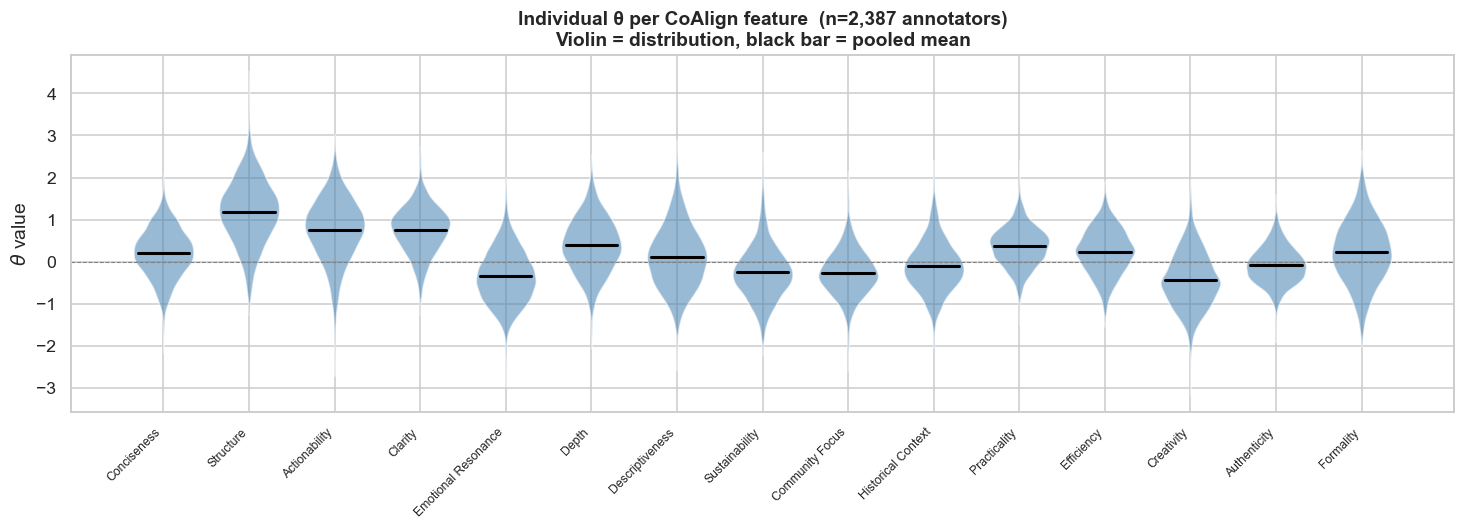

In [5]:
# Violin plot: individual θ per feature dimension (black bar = pooled mean across agents)
fig, ax = plt.subplots(figsize=(max(12, 0.9 * K_DIM), 5))

data_list = [Theta[:, i] for i in range(K_DIM)]
parts = ax.violinplot(data_list, positions=range(K_DIM),
                      showmedians=False, showextrema=False, widths=0.7)
for pc in parts["bodies"]:
    pc.set_facecolor("steelblue")
    pc.set_alpha(0.55)

means = Theta.mean(axis=0)
for i, m in enumerate(means):
    ax.plot([i - 0.3, i + 0.3], [m, m], color="black", lw=2.0, zorder=4)

ax.axhline(0, color="grey", ls="--", lw=0.7)
ax.set_xticks(range(K_DIM))
ax.set_xticklabels(DIM_NAMES, rotation=45, ha="right", fontsize=8)
ax.set_ylabel(r"$\theta$ value")
ax.set_title(f"Individual θ per CoAlign feature  (n={N_AGENTS:,} annotators)\n"
             "Violin = distribution, black bar = pooled mean", fontweight="bold")
plt.tight_layout()
plt.show()

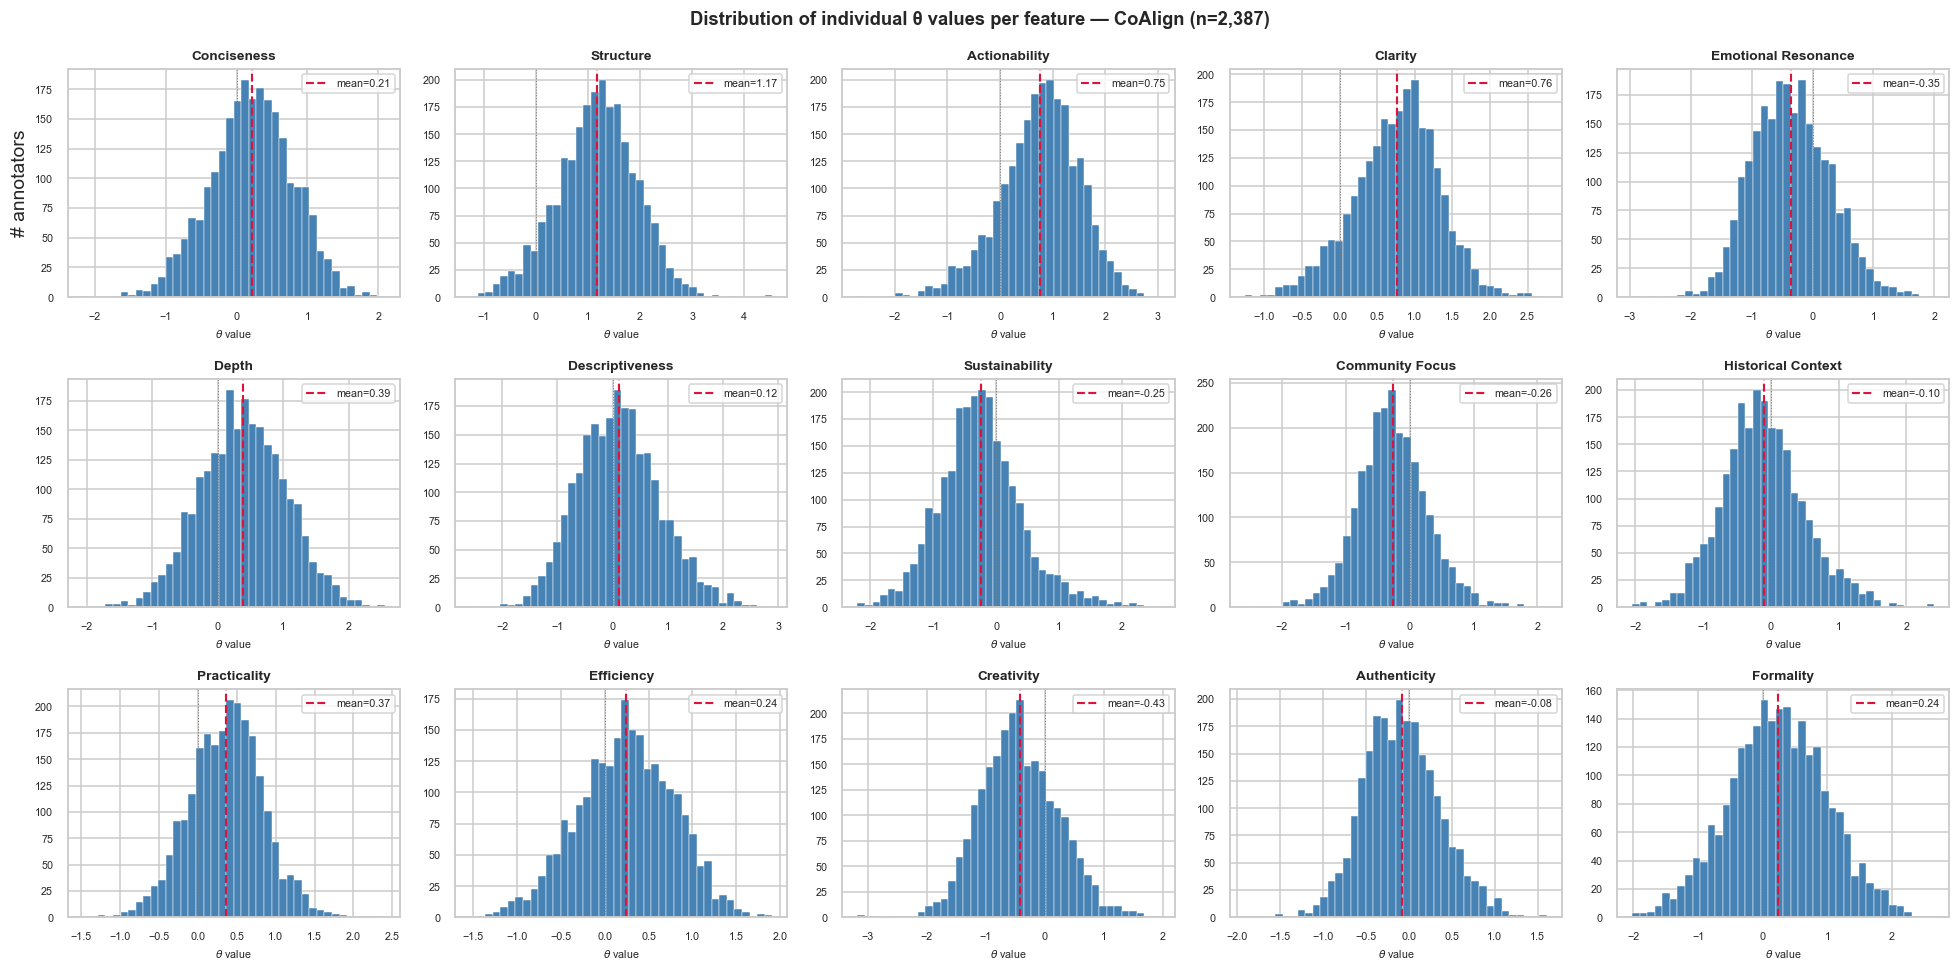

In [6]:
# Histogram grid: one panel per feature (3×5 = 15 panels for K_DIM=15; auto-shapes if K_DIM differs)
n_cols = 5
n_rows = int(np.ceil(K_DIM / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.0 * n_rows))
axes_flat = axes.flatten()

for ax, feat, i in zip(axes_flat, DIM_NAMES, range(K_DIM)):
    vals = Theta[:, i]
    ax.hist(vals, bins=40, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.axvline(vals.mean(), color="crimson", lw=1.4, ls="--",
               label=f"mean={vals.mean():.2f}")
    ax.axvline(0, color="grey", lw=0.7, ls=":")
    ax.set_title(feat, fontweight="bold", fontsize=9)
    ax.set_xlabel(r"$\theta$ value", fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

for ax in axes_flat[K_DIM:]:
    ax.set_visible(False)

axes_flat[0].set_ylabel("# annotators")
plt.suptitle(f"Distribution of individual θ values per feature — CoAlign (n={N_AGENTS:,})",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

## §3. β-sweep — precompute per-agent welfare for three mechanisms

For each β on a log grid we compute, for the three deployment θ_c:

- Utilitarian: $\bar\theta_w$
- RLHF: $\hat\theta$
- Strategyproof: $\theta_{sp}(\beta)$ (β-dependent, fitted via inverse impact map)

…the per-agent welfare $W_n(\theta_c;\beta) / W^*$, then derive every downstream metric (mean, max, min, argmax, argmin, Gini, variance) from the same precomputed arrays. Because `alpha_train` is large (~M·2 rows) we sample `QUERY_SAMPLE` queries for the inner sweep — raise it for more precision.

In [7]:
# Build alpha_q (deployment query distribution) — subsample for sweep speed
QUERY_SAMPLE = 5000
rng_q = np.random.default_rng(0)
if alpha_train.shape[0] > QUERY_SAMPLE:
    idx = rng_q.choice(alpha_train.shape[0], size=QUERY_SAMPLE, replace=False)
    alpha_q = alpha_train[idx]
else:
    alpha_q = alpha_train
print(f"alpha_q (deployment queries): {alpha_q.shape}")

# Helpers (mirror moralmachine notebook)
def phi_all(theta_agents, beta, alpha):
    logits = alpha @ theta_agents.T            # (M, N)
    factor = (sigmoid(beta * logits) - 0.5)    # (M, N)
    return factor.T @ alpha / len(alpha)       # (N, K)

def phi_inv(target, beta, alpha, theta_init=None):
    if theta_init is None:
        theta_init = np.zeros(alpha.shape[1])
    def loss_and_grad(theta):
        s        = sigmoid(beta * (alpha @ theta))
        phi_t    = ((s - 0.5)[:, None] * alpha).mean(axis=0)
        residual = phi_t - target
        v        = s * (1 - s)
        J        = (alpha * (beta * v)[:, None]).T @ alpha / len(alpha)
        return 0.5 * np.dot(residual, residual), J @ residual
    res = minimize(loss_and_grad, theta_init, jac=True, method="L-BFGS-B",
                   options={"maxiter": 500, "ftol": 1e-14, "gtol": 1e-8})
    return res.x

def per_agent_welfare(theta_deploy, beta, theta_agents, alpha):
    factor = (sigmoid(beta * (alpha @ theta_deploy)) - 0.5)
    return (alpha @ theta_agents.T * factor[:, None]).mean(axis=0)

# Utilitarian-optimal impact ψ* and ideal welfare W* = θ̄ · ψ*
psi_star = (np.sign(alpha_q @ theta_bar)[:, None] * alpha_q).mean(axis=0)
W_star   = float(theta_bar @ psi_star)
print(f"W* (utilitarian boundary optimal) = {W_star:.4f}")

alpha_q (deployment queries): (5000, 15)
W* (utilitarian boundary optimal) = 0.6652


In [25]:
# Sweep β and store W_n(θ_c; β) / W* for each mechanism, each β
betas = np.logspace(-2, 2, 100)        # widened to put β_calib=1 at center; covers wash-out and saturation
MECH  = ["Utilitarian", "RLHF", "Strategyproof"]

W_per_agent = {lbl: np.zeros((len(betas), N_AGENTS)) for lbl in MECH}
theta_sp_track = np.zeros((len(betas), K_DIM))

theta_sp_prev = theta_bar.copy()
import time
t0 = time.time()
for j, b in enumerate(betas):
    phi_avg       = phi_all(Theta, b, alpha_q).mean(axis=0)
    theta_sp      = phi_inv(phi_avg, b, alpha_q, theta_init=theta_sp_prev)
    theta_sp_prev = theta_sp.copy()
    theta_sp_track[j] = theta_sp

    W_per_agent["Utilitarian"][j]   = per_agent_welfare(theta_bar,   b, Theta, alpha_q) / W_star
    W_per_agent["RLHF"][j]          = per_agent_welfare(theta_rlhf,  b, Theta, alpha_q) / W_star
    W_per_agent["Strategyproof"][j] = per_agent_welfare(theta_sp,    b, Theta, alpha_q) / W_star

    if (j + 1) % 10 == 0 or j == 0:
        print(f"  β-sweep {j+1:3d}/{len(betas)}   β={b:7.3f}   "
              f"elapsed {time.time()-t0:5.1f}s")
print(f"sweep complete: {time.time()-t0:.1f}s for {len(betas)} β values × {N_AGENTS:,} agents")

# Aggregates derived from W_per_agent — used by every downstream plot
agg = {}
for lbl in MECH:
    W = W_per_agent[lbl]   # (n_beta, N)
    agg[lbl] = {
        "mean":   W.mean(axis=1),
        "max":    W.max(axis=1),
        "min":    W.min(axis=1),
        "argmax": W.argmax(axis=1),
        "argmin": W.argmin(axis=1),
        "var":    W.var(axis=1),
    }

  β-sweep   1/100   β=  0.010   elapsed   0.4s
  β-sweep  10/100   β=  0.023   elapsed   6.5s
  β-sweep  20/100   β=  0.059   elapsed  12.8s
  β-sweep  30/100   β=  0.148   elapsed  19.8s
  β-sweep  40/100   β=  0.376   elapsed  28.0s
  β-sweep  50/100   β=  0.955   elapsed  37.1s
  β-sweep  60/100   β=  2.420   elapsed  49.6s
  β-sweep  70/100   β=  6.136   elapsed  60.8s
  β-sweep  80/100   β= 15.557   elapsed  84.3s
  β-sweep  90/100   β= 39.442   elapsed 105.0s
  β-sweep 100/100   β=100.000   elapsed 129.7s
sweep complete: 129.7s for 100 β values × 2,387 agents


## §4. Social welfare vs β

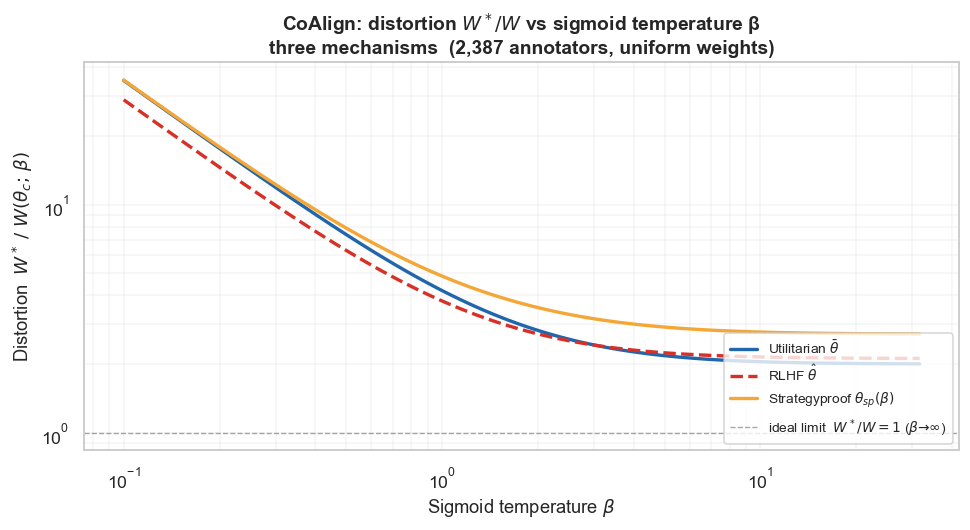

W* = 0.6652


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
mech_styles = {"Utilitarian":   ("#2166ac", "-",  r"Utilitarian $\bar\theta$"),
               "RLHF":          ("#d73027", "--", r"RLHF $\hat\theta$"),
               "Strategyproof": ("#f4a736", "-",  r"Strategyproof $\theta_{sp}(\beta)$")}
for lbl in MECH:
    c, ls, leg = mech_styles[lbl]
    ax.plot(betas, 1.0 / agg[lbl]["mean"], color=c, ls=ls, lw=2.2, label=leg)
ax.axhline(1.0, color="grey", ls="--", lw=0.9, alpha=0.7,
           label=r"ideal limit  $W^*/W = 1$ ($\beta\to\infty$)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"Sigmoid temperature $\beta$", fontsize=12)
ax.set_ylabel(r"Distortion  $W^*\;/\;W(\theta_c;\,\beta)$", fontsize=12)
ax.set_title(f"CoAlign: distortion $W^*/W$ vs sigmoid temperature β\n"
             f"three mechanisms  ({N_AGENTS:,} annotators, uniform weights)",
             fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, which="both", alpha=0.2)
plt.tight_layout()
plt.show()
print(f"W* = {W_star:.4f}")

## §5. Best-off / worst-off welfare bounds vs β

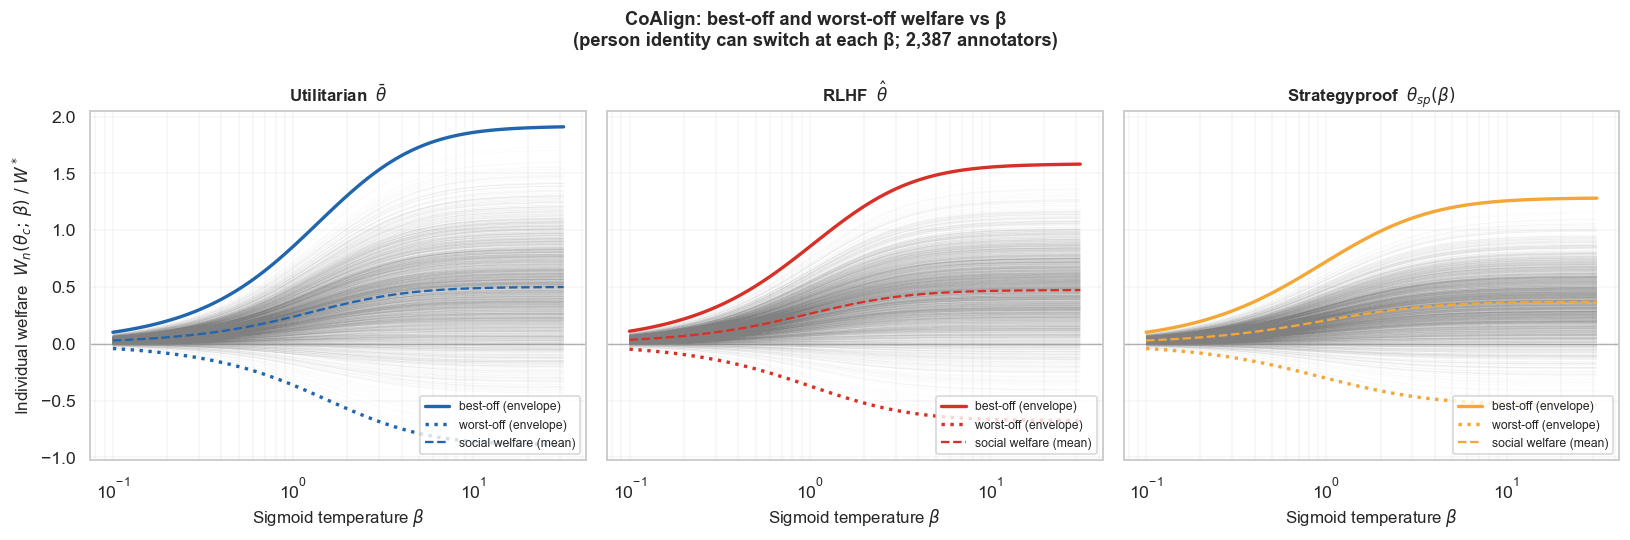

Utilitarian     β=31.6: min -0.8879  max +1.9092
RLHF            β=31.6: min -0.6758  max +1.5807
Strategyproof   β=31.6: min -0.5371  max +1.2813


In [10]:
mech_colors = {"Utilitarian": "#2166ac", "RLHF": "#d73027", "Strategyproof": "#f4a736"}
mech_titles = {"Utilitarian": r"Utilitarian  $\bar\theta$",
               "RLHF":        r"RLHF  $\hat\theta$",
               "Strategyproof": r"Strategyproof  $\theta_{sp}(\beta)$"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, lbl in zip(axes, MECH):
    c = mech_colors[lbl]; rec = agg[lbl]
    # Individual welfare trajectories (thin gray spaghetti — one line per agent)
    ax.plot(betas, W_per_agent[lbl], color="gray", alpha=0.05, lw=0.3, zorder=1)
    # Best-off / worst-off envelopes (bold)
    ax.plot(betas, rec["max"],  color=c, lw=2.2, ls="-",  label="best-off (envelope)", zorder=4)
    ax.plot(betas, rec["min"],  color=c, lw=2.2, ls=":",  label="worst-off (envelope)", zorder=4)
    ax.plot(betas, rec["mean"], color=c, lw=1.5, ls="--", label="social welfare (mean)", zorder=3)
    ax.axhline(0, color="grey", lw=0.9, ls="-", alpha=0.6)
    ax.set_xscale("log")
    ax.set_xlabel(r"Sigmoid temperature $\beta$", fontsize=11)
    ax.set_title(mech_titles[lbl], fontweight="bold", fontsize=11)
    ax.grid(True, which="both", alpha=0.18)
    ax.legend(fontsize=8, loc="lower right")

axes[0].set_ylabel(r"Individual welfare  $W_n(\theta_c;\,\beta)\;/\;W^*$", fontsize=11)
fig.suptitle(f"CoAlign: best-off and worst-off welfare vs β\n"
             f"(person identity can switch at each β; {N_AGENTS:,} annotators)",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

for lbl in MECH:
    print(f"{lbl:14s}  β={betas[-1]:.1f}: min {agg[lbl]['min'][-1]:+.4f}  max {agg[lbl]['max'][-1]:+.4f}")

## §6. Best-off / worst-off agent identity vs β

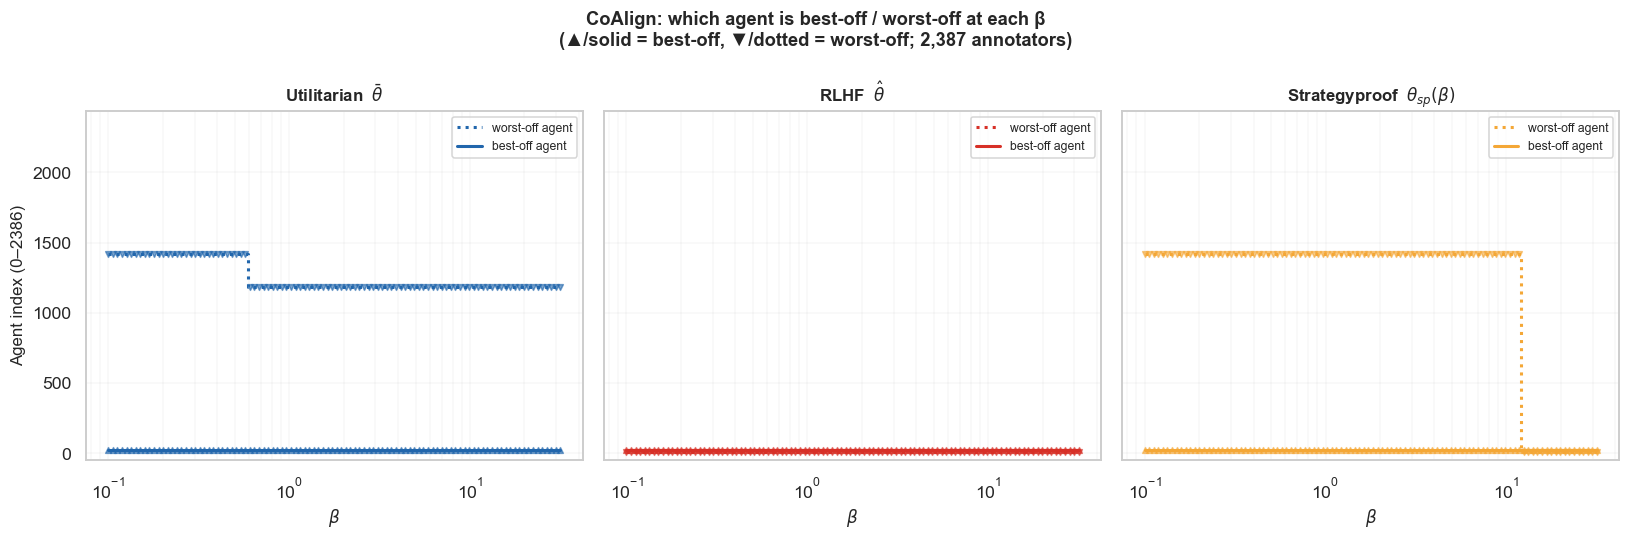

Worst-off agent (argmin) summary (agent index):
  Utilitarian   : top-5 [(1182, 69), (1420, 31)]  n_switches=1  n_distinct=2
  RLHF          : top-5 [(13, 100)]  n_switches=0  n_distinct=1
  Strategyproof : top-5 [(1420, 83), (13, 17)]  n_switches=1  n_distinct=2

Best-off agent (argmax) summary (agent index):
  Utilitarian   : top-5 [(22, 100)]  n_switches=0  n_distinct=1
  RLHF          : top-5 [(22, 100)]  n_switches=0  n_distinct=1
  Strategyproof : top-5 [(22, 100)]  n_switches=0  n_distinct=1


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, lbl in zip(axes, MECH):
    c = mech_colors[lbl]
    amin_idx = agg[lbl]["argmin"]
    amax_idx = agg[lbl]["argmax"]
    ax.step(betas, amin_idx, where="mid", color=c, lw=2.0, ls=":", label="worst-off agent")
    ax.step(betas, amax_idx, where="mid", color=c, lw=2.0, ls="-", label="best-off agent")
    ax.scatter(betas, amin_idx, color=c, s=14, alpha=0.6, marker="v", zorder=3)
    ax.scatter(betas, amax_idx, color=c, s=14, alpha=0.6, marker="^", zorder=3)
    ax.set_xscale("log")
    ax.set_xlabel(r"$\beta$", fontsize=11)
    ax.set_ylim(-50, N_AGENTS + 50)
    ax.set_title(mech_titles[lbl], fontweight="bold", fontsize=11)
    ax.grid(True, which="both", alpha=0.15)
    ax.legend(fontsize=8, loc="best")

axes[0].set_ylabel(f"Agent index (0–{N_AGENTS-1})", fontsize=11)
fig.suptitle(f"CoAlign: which agent is best-off / worst-off at each β\n"
             f"(▲/solid = best-off, ▼/dotted = worst-off; {N_AGENTS:,} annotators)",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

print("Worst-off agent (argmin) summary (agent index):")
for lbl in MECH:
    idxs = agg[lbl]["argmin"].tolist()
    cnt  = Counter(idxs)
    top5 = sorted(cnt.items(), key=lambda x: -x[1])[:5]
    n_switches = sum(1 for i in range(1, len(idxs)) if idxs[i] != idxs[i-1])
    print(f"  {lbl:14s}: top-5 {top5}  n_switches={n_switches}  n_distinct={len(cnt)}")

print("\nBest-off agent (argmax) summary (agent index):")
for lbl in MECH:
    idxs = agg[lbl]["argmax"].tolist()
    cnt  = Counter(idxs)
    top5 = sorted(cnt.items(), key=lambda x: -x[1])[:5]
    n_switches = sum(1 for i in range(1, len(idxs)) if idxs[i] != idxs[i-1])
    print(f"  {lbl:14s}: top-5 {top5}  n_switches={n_switches}  n_distinct={len(cnt)}")

## §7. Welfare inequality (Gini) vs β

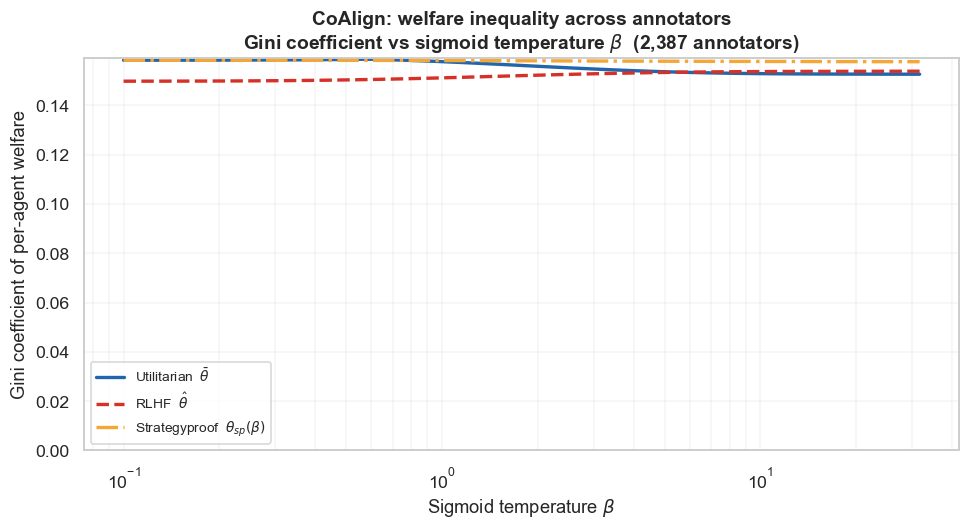

Utilitarian     β=0.10: 0.158   β=1: 0.158   β=31.6: 0.153
RLHF            β=0.10: 0.150   β=1: 0.151   β=31.6: 0.154
Strategyproof   β=0.10: 0.158   β=1: 0.158   β=31.6: 0.158


In [12]:
def gini(values):
    v = np.asarray(values, dtype=float)
    v = v - v.min()
    if v.sum() < 1e-12:
        return 0.0
    v = np.sort(v)
    N = len(v)
    return float((2 * (np.arange(1, N + 1) * v).sum()) / (N * v.sum()) - (N + 1) / N)

gini_traces = {lbl: np.array([gini(W_per_agent[lbl][j]) for j in range(len(betas))]) for lbl in MECH}

fig, ax = plt.subplots(figsize=(9, 5))
for lbl, ls in zip(MECH, ["-", "--", "-."]):
    ax.plot(betas, gini_traces[lbl], color=mech_colors[lbl], lw=2.2, ls=ls,
            label=mech_titles[lbl])
ax.set_xscale("log")
ax.set_ylim(bottom=0)
ax.set_xlabel(r"Sigmoid temperature $\beta$", fontsize=12)
ax.set_ylabel("Gini coefficient of per-agent welfare", fontsize=12)
ax.set_title(f"CoAlign: welfare inequality across annotators\n"
             r"Gini coefficient vs sigmoid temperature $\beta$"
             f"  ({N_AGENTS:,} annotators)", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.2)
plt.tight_layout()
plt.show()

mid = int(np.argmin(np.abs(betas - 1)))
for lbl in MECH:
    g = gini_traces[lbl]
    print(f"{lbl:14s}  β={betas[0]:.2f}: {g[0]:.3f}   β=1: {g[mid]:.3f}   β={betas[-1]:.1f}: {g[-1]:.3f}")

## §8. Welfare variance vs β

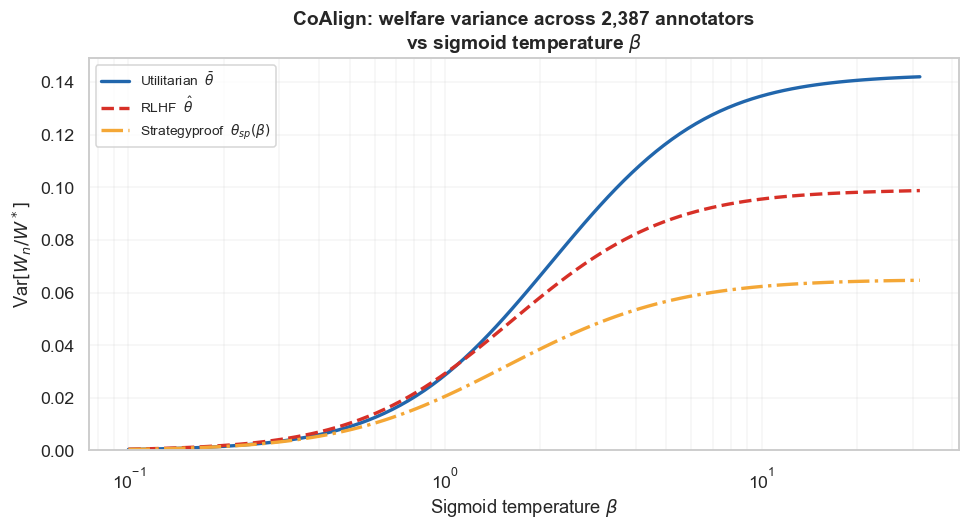

Utilitarian     β=0.10: 0.0004   β=1: 0.0296   β=31.6: 0.1420
RLHF            β=0.10: 0.0005   β=1: 0.0301   β=31.6: 0.0988
Strategyproof   β=0.10: 0.0004   β=1: 0.0211   β=31.6: 0.0647


In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
for lbl, ls in zip(MECH, ["-", "--", "-."]):
    ax.plot(betas, agg[lbl]["var"], color=mech_colors[lbl], lw=2.2, ls=ls,
            label=mech_titles[lbl])
ax.set_xscale("log")
ax.set_ylim(bottom=0)
ax.set_xlabel(r"Sigmoid temperature $\beta$", fontsize=12)
ax.set_ylabel(r"Var$[W_n / W^*]$", fontsize=12)
ax.set_title(f"CoAlign: welfare variance across {N_AGENTS:,} annotators\n"
             r"vs sigmoid temperature $\beta$", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.2)
plt.tight_layout()
plt.show()

mid = int(np.argmin(np.abs(betas - 1)))
for lbl in MECH:
    v = agg[lbl]["var"]
    print(f"{lbl:14s}  β={betas[0]:.2f}: {v[0]:.4f}   β=1: {v[mid]:.4f}   β={betas[-1]:.1f}: {v[-1]:.4f}")

## §9. Welfare-constrained alignment

Given the linear-impact-space framework, any constrained linear social choice problem

$$\psi^{\rm wel}\in\arg\max_{\psi\in\bar\Psi}\;\bar\theta_w^\top\psi\quad\text{s.t.}\quad\nu_n^\top\psi\ge c_n\;\forall n$$

is an LP over the polytope $\bar\Psi=\mathrm{conv}\{\tfrac12\,\alpha_z\,s:s\in\{\pm1\}\}$.
By Theorem 1.4 the optimum is the unconstrained boundary point in the *reweighted* direction
$d=\bar\theta_w+\sum_n\eta_n\nu_n$, where $\eta_n\ge0$ are KKT multipliers (positive only when constraint $n$ binds).

We solve via dual subgradient ascent on $\eta$:

* Inner maximization (closed form): $\psi(d)=\tfrac12\,\mathbb E_\alpha[\alpha\,\mathrm{sign}(\alpha^\top d)]$.
* Outer update: $\eta_n\leftarrow\max\!\big(0,\,\eta_n+\gamma(c_n-\nu_n^\top\psi)\big)$.
* Polyak average $\bar\psi=\frac1{T-T_0}\sum_{t>T_0}\psi^{(t)}$ for stability (the iterates flip between vertices).

In [14]:
# Shared LP solver via dual subgradient + Polyak averaging
def support_func(d, alpha_dep):
    # h_Ψ(d) = max_{ψ ∈ Ψ̄} d^T ψ = 0.5 · E[|α^T d|]
    return 0.5 * float(np.abs(alpha_dep @ d).mean())

def solve_constrained_alignment(theta_obj, normals, thresholds, alpha_dep,
                                lr=1.0, n_iter=600, burn_in=100, eta_tol=1e-6,
                                verbose=False):
    # max  theta_obj^T ψ      s.t.  normals_n @ ψ ≥ thresholds_n,   ψ ∈ Ψ̄.
    # Returns (ψ_avg, η_final, history).
    N, k = normals.shape
    eta     = np.zeros(N)
    psi_acc = np.zeros(k); n_acc = 0
    history = {"obj": [], "max_viol": [], "n_binding": []}
    for it in range(n_iter):
        d      = theta_obj + eta @ normals
        s      = np.sign(alpha_dep @ d)
        psi    = 0.5 * (alpha_dep * s[:, None]).mean(axis=0)
        slacks = normals @ psi - thresholds            # negative ⇒ violated
        eta    = np.maximum(0.0, eta + lr * (-slacks))
        if it >= burn_in:
            psi_acc += psi; n_acc += 1
        history["obj"].append(float(theta_obj @ psi))
        history["max_viol"].append(float(np.maximum(0.0, -slacks).max()))
        history["n_binding"].append(int((eta > eta_tol).sum()))
        if verbose and it % 100 == 0:
            print(f"  iter {it:4d}  obj={history['obj'][-1]:+.4f}  "
                  f"max_viol={history['max_viol'][-1]:.2e}  n_binding={history['n_binding'][-1]}")
    psi_avg = psi_acc / max(n_acc, 1)
    return psi_avg, eta, history

print("solver ready.  ψ ∈ Ψ̄ defined by alpha_q (deployment queries).")
print(f"  alpha_q: {alpha_q.shape}     N_AGENTS: {N_AGENTS}     K_DIM: {K_DIM}")

solver ready.  ψ ∈ Ψ̄ defined by alpha_q (deployment queries).
  alpha_q: (5000, 15)     N_AGENTS: 2387     K_DIM: 15


### §9.1 Bounded harm

Floor each agent's welfare:  $\theta_n^\top\psi\ge b_n\;\forall n$.

Three natural floors (cf. Cor. *bounded-harm*):
1. $b_n=0$ — every agent at least as well off as random (coin-flip).
2. $b_n=\theta_n^\top\psi^{\rm RLHF}$ — every agent prefers the bounded-harm mechanism over deployed RLHF.
3. $b_n=-\varepsilon\,h_{\bar\Psi}(\theta_n)$ — bounded relative loss: agent loses at most fraction $\varepsilon$ of their max achievable welfare.

We compute (1) at $\varepsilon=0$, then sweep (3) over $\varepsilon\in[0,1]$ to trace the social-welfare/floor frontier.

In [15]:
# (1) Bounded harm with floor b_n = 0  (no agent worse than random)
b_zero = np.zeros(N_AGENTS)
psi_h0, eta_h0, hist_h0 = solve_constrained_alignment(
    theta_bar, Theta, b_zero, alpha_q, lr=2.0, n_iter=600, burn_in=100, verbose=True)

W_h0       = float(theta_bar @ psi_h0)
W_h0_n     = Theta @ psi_h0
W_util_n   = Theta @ psi_star
n_binding  = int((eta_h0 > 1e-6).sum())
n_violated_util = int((W_util_n < -1e-9).sum())
worst_util = float(W_util_n.min())
worst_h0   = float(W_h0_n.min())

print(f"\nbounded harm (b=0)")
print(f"  social welfare W^h / W*           = {W_h0/W_star:+.4f}")
print(f"  social welfare loss vs util       = {(W_star - W_h0)/W_star:.2%}")
print(f"  binding coalition |B|             = {n_binding} / {N_AGENTS}  ({n_binding/N_AGENTS:.1%})")
print(f"  worst per-agent welfare under util= {worst_util:+.4f}    (#agents < 0: {n_violated_util})")
print(f"  worst per-agent welfare under h(0)= {worst_h0:+.4f}    (floor obeyed: {worst_h0 >= -1e-6})")

top = np.argsort(-eta_h0)[:10]
print(f"\nTop 10 agents by shadow price η (most constrained):")
for n in top:
    print(f"  agent {n:4d}  η={eta_h0[n]:+.4f}  W_util={W_util_n[n]:+.4f}  W^h={W_h0_n[n]:+.4f}  group={groups[n]}")

  iter    0  obj=+0.3326  max_viol=5.95e-01  n_binding=208
  iter  100  obj=+0.3263  max_viol=7.19e-01  n_binding=441
  iter  200  obj=+0.3257  max_viol=7.23e-01  n_binding=849
  iter  300  obj=+0.3263  max_viol=7.19e-01  n_binding=918
  iter  400  obj=+0.3254  max_viol=7.26e-01  n_binding=735
  iter  500  obj=+0.3254  max_viol=7.26e-01  n_binding=672

bounded harm (b=0)
  social welfare W^h / W*           = +0.0084
  social welfare loss vs util       = 99.16%
  binding coalition |B|             = 2173 / 2387  (91.0%)
  worst per-agent welfare under util= -1.1901    (#agents < 0: 208)
  worst per-agent welfare under h(0)= -0.0061    (floor obeyed: False)

Top 10 agents by shadow price η (most constrained):
  agent   13  η=+8.7609  W_util=-1.0238  W^h=-0.0061  group=india
  agent  486  η=+8.3348  W_util=-0.9022  W^h=-0.0057  group=india
  agent  873  η=+7.5777  W_util=-0.4726  W^h=-0.0048  group=france
  agent 1176  η=+6.4137  W_util=-0.5142  W^h=-0.0042  group=united states
  agent  39

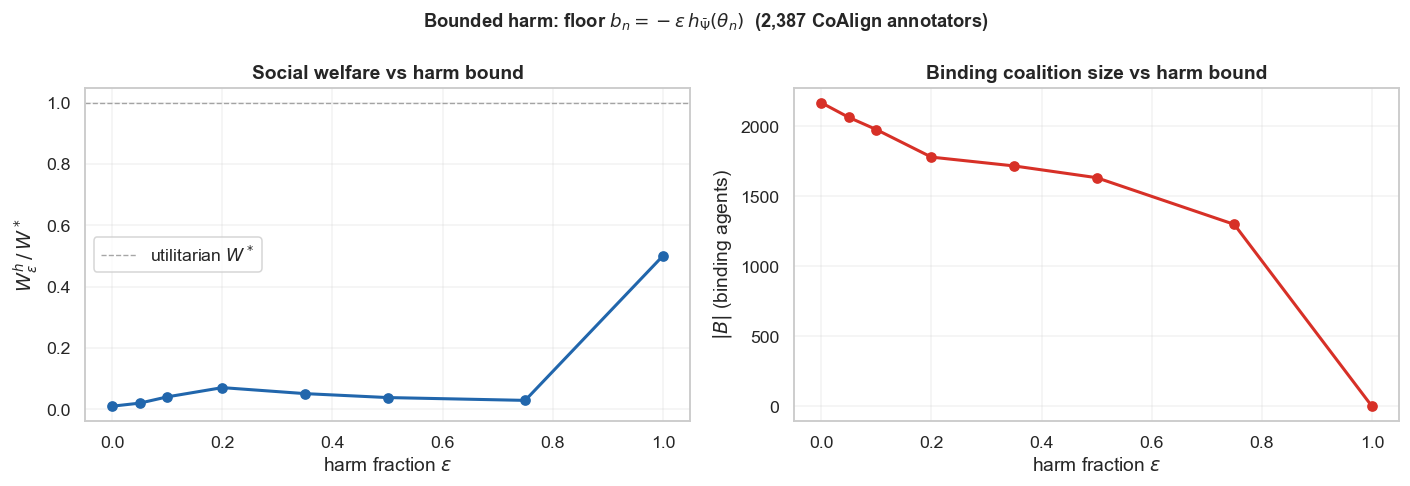

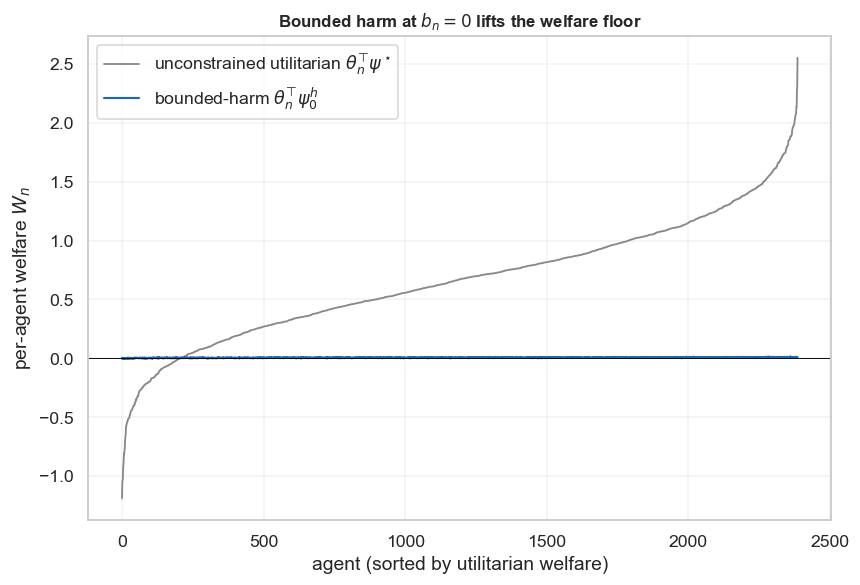

In [16]:
# Sweep ε for b_n = -ε · h_Ψ̄(θ_n)
hub = 0.5 * np.abs(alpha_q @ Theta.T).mean(axis=0)   # h_Ψ̄(θ_n) per agent — vector form

epsilons   = np.array([0.0, 0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0])
W_eps      = np.zeros_like(epsilons)
nbind_eps  = np.zeros_like(epsilons, dtype=int)

for i, eps in enumerate(epsilons):
    b   = -eps * hub
    psi_e, eta_e, _ = solve_constrained_alignment(
        theta_bar, Theta, b, alpha_q, lr=2.0, n_iter=400, burn_in=80)
    W_eps[i]     = float(theta_bar @ psi_e)
    nbind_eps[i] = int((eta_e > 1e-6).sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(epsilons, W_eps / W_star, "o-", color="#2166ac", lw=2)
axes[0].axhline(1.0, color="grey", ls="--", lw=0.9, alpha=0.7, label="utilitarian $W^*$")
axes[0].set_xlabel(r"harm fraction $\varepsilon$"); axes[0].set_ylabel(r"$W^h_\varepsilon\,/\,W^*$")
axes[0].set_title("Social welfare vs harm bound", fontweight="bold")
axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].plot(epsilons, nbind_eps, "o-", color="#d73027", lw=2)
axes[1].set_xlabel(r"harm fraction $\varepsilon$"); axes[1].set_ylabel(r"$|B|$ (binding agents)")
axes[1].set_title("Binding coalition size vs harm bound", fontweight="bold")
axes[1].grid(alpha=0.25)

fig.suptitle(r"Bounded harm: floor $b_n = -\varepsilon\,h_{\bar\Psi}(\theta_n)$"
             f"  ({N_AGENTS:,} CoAlign annotators)", fontweight="bold", fontsize=12)
plt.tight_layout(); plt.show()

# Per-agent welfare comparison: util vs bounded-harm at b=0
fig, ax = plt.subplots(figsize=(8, 5.5))
order = np.argsort(W_util_n)
ax.plot(W_util_n[order], lw=1.2, color="#888", label=r"unconstrained utilitarian $\theta_n^\top\psi^\star$")
ax.plot((Theta @ psi_h0)[order], lw=1.4, color="#2166ac", label=r"bounded-harm $\theta_n^\top\psi^h_0$")
ax.axhline(0, color="black", lw=0.6)
ax.set_xlabel("agent (sorted by utilitarian welfare)")
ax.set_ylabel(r"per-agent welfare $W_n$")
ax.set_title("Bounded harm at $b_n=0$ lifts the welfare floor",
             fontweight="bold", fontsize=11)
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

### §9.2 Public spirit

Each agent has a public-spirit parameter $\gamma\in[0,1]$:

$$(\gamma\bar\theta_w+(1-\gamma)\theta_n)^\top\psi\ \ge\ (\gamma\bar\theta_w+(1-\gamma)\theta_n)^\top\psi_0\quad\forall n.$$

Equivalently — agent $n$ accepts personal loss only when justified by social gain:

$$(1-\gamma)\,\theta_n^\top(\psi_0-\psi)\ \le\ \gamma\,\bar\theta_w^\top(\psi-\psi_0).$$

* $\gamma=0$ — only Pareto improvements over $\psi_0$ allowed (no agent worse off than under $\psi_0$).
* $\gamma=1$ — agents evaluate by aggregate alone; per-agent constraints collapse to $\bar\theta_w^\top\psi\ge\bar\theta_w^\top\psi_0$ (redundant when $\bar\theta_w^\top\psi^\star \ge \bar\theta_w^\top\psi_0$).

**Reference choice matters.** With $\psi_0=0$ and a heterogeneous population (whose $\theta_n$ positively span $\mathbb{R}^K$), strict IR forces $\psi=0$ — no movement at all is feasible. We instead use $\psi_0=\psi^\infty_{\rm RLHF}$ (asymptotic deployed RLHF), so $\gamma=0$ means "no agent worse than under RLHF" — a meaningful IR-vs-status-quo constraint.

reference ψ_0 = ψ_RLHF^∞ :  ||ψ_0|| = 0.2522,  W(ψ_0) = +0.3153   (+0.474 × W*)


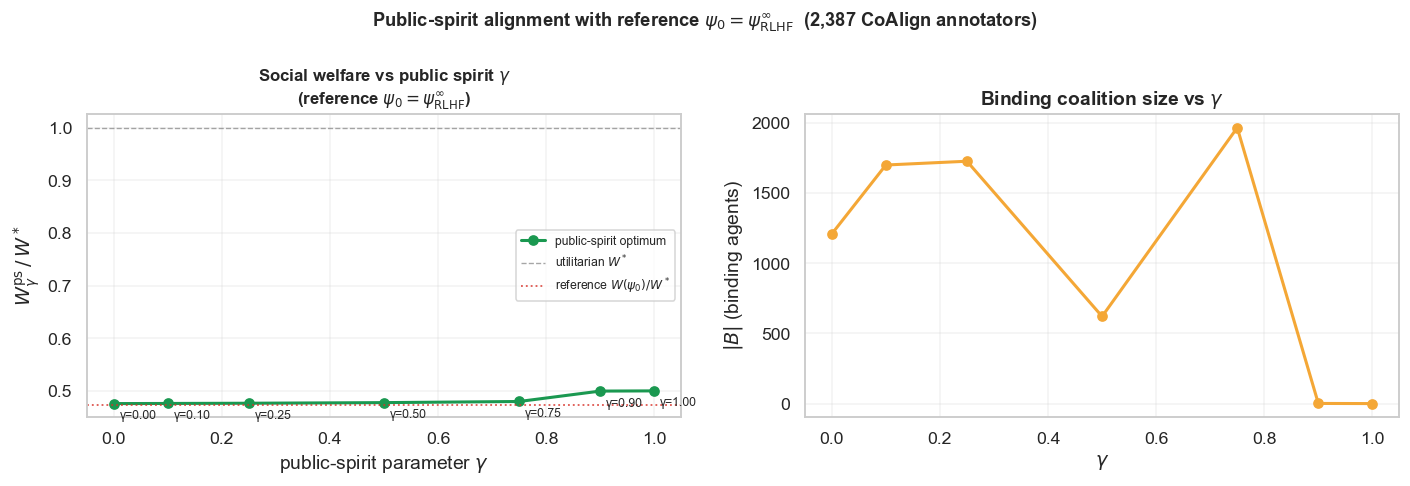


       γ      W/W*     |B|    cos(ψ_γ, ψ*)
    0.00  +0.4759    1209        +0.9923
    0.10  +0.4761    1700        +0.9923
    0.25  +0.4765    1727        +0.9923
    0.50  +0.4777     621        +0.9924
    0.75  +0.4798    1966        +0.9936
    0.90  +0.4996       1        +0.9998
    1.00  +0.5000       0        +1.0000


In [17]:
# Public spirit: sweep γ ∈ [0, 1] with ψ_0 = ψ_RLHF^∞ (asymptotic deployed RLHF).
# Using ψ_0 = 0 instead would force ψ=0 at γ=0 (strict IR vs random is infeasible
# when θ_n's span R^K, which is virtually always the case for heterogeneous populations).

psi_0_ps = 0.5 * (alpha_q * np.sign(alpha_q @ theta_rlhf)[:, None]).mean(axis=0)
W0       = float(theta_bar @ psi_0_ps)
print(f"reference ψ_0 = ψ_RLHF^∞ :  ||ψ_0|| = {np.linalg.norm(psi_0_ps):.4f},  "
      f"W(ψ_0) = {W0:+.4f}   ({W0/W_star:+.3f} × W*)")

gammas    = np.array([0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0])
W_g       = np.zeros_like(gammas)
nbind_g   = np.zeros_like(gammas, dtype=int)
psi_g_arr = np.zeros((len(gammas), K_DIM))

for i, g in enumerate(gammas):
    G_normals = g * theta_bar[None, :] + (1.0 - g) * Theta
    c         = G_normals @ psi_0_ps
    psi_n, eta_n, _ = solve_constrained_alignment(
        theta_bar, G_normals, c, alpha_q, lr=2.0, n_iter=600, burn_in=100)
    W_g[i]      = float(theta_bar @ psi_n)
    nbind_g[i]  = int((eta_n > 1e-6).sum())
    psi_g_arr[i] = psi_n

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(gammas, W_g / W_star, "o-", color="#1a9850", lw=2, label="public-spirit optimum")
axes[0].axhline(1.0,         color="grey",  ls="--", lw=0.9, alpha=0.7, label=r"utilitarian $W^*$")
axes[0].axhline(W0 / W_star, color="#d73027", ls=":",  lw=1.2, alpha=0.8, label=r"reference $W(\psi_0)/W^*$")
axes[0].set_xlabel(r"public-spirit parameter $\gamma$"); axes[0].set_ylabel(r"$W^{\rm ps}_\gamma\,/\,W^*$")
axes[0].set_title(r"Social welfare vs public spirit $\gamma$" "\n" r"(reference $\psi_0=\psi^\infty_{\rm RLHF}$)",
                  fontweight="bold", fontsize=11)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25)
for i, g in enumerate(gammas):
    axes[0].annotate(f"γ={g:.2f}", (gammas[i], W_g[i]/W_star),
                     xytext=(4, -10), textcoords="offset points", fontsize=8)

axes[1].plot(gammas, nbind_g, "o-", color="#f4a736", lw=2)
axes[1].set_xlabel(r"$\gamma$"); axes[1].set_ylabel(r"$|B|$ (binding agents)")
axes[1].set_title(r"Binding coalition size vs $\gamma$", fontweight="bold")
axes[1].grid(alpha=0.25)

fig.suptitle(f"Public-spirit alignment with reference $\\psi_0=\\psi^\\infty_{{\\rm RLHF}}$  "
             f"({N_AGENTS:,} CoAlign annotators)", fontweight="bold", fontsize=12)
plt.tight_layout(); plt.show()

print(f"\n{'γ':>8s}  {'W/W*':>8s}  {'|B|':>6s}  {'cos(ψ_γ, ψ*)':>14s}")
for i, g in enumerate(gammas):
    cs = float(psi_g_arr[i] @ psi_star) / (np.linalg.norm(psi_g_arr[i]) * np.linalg.norm(psi_star) + 1e-12)
    print(f"  {g:6.2f}  {W_g[i]/W_star:>+7.4f}  {nbind_g[i]:>6d}  {cs:>+13.4f}")

### §9.3 Best-off / worst-off welfare under welfare-constrained mechanisms

For each constrained $\psi^{\rm wel}$, Theorem 1.4 gives $\psi^{\rm wel}=\arg\max_{\psi\in\bar\Psi}\,d^\top\psi$ where
$d=\bar\theta_w+\sum_n\eta_n\nu_n$. We treat $d$ as the effective deployment $\theta_c$ that "deploys" the constrained mechanism, then run the §5-style worst-/best-off β-sweep with $W_n(\theta_c;\beta)/W^*$.

* Bounded harm $(b=0)$: $\theta_c=\bar\theta_w+\sum_n\eta_n\theta_n$.
* Public spirit $(\nu)$: $\theta_c=(1+\nu\sum_n\eta_n)\bar\theta_w+\sum_n\eta_n\theta_n$.

In [18]:
# Re-solve all six mechanisms via scipy.linprog (exact LP, HiGHS).
from scipy.optimize import linprog

def solve_constrained_lp(theta_obj, normals, thresholds, alpha_dep, verbose=False):
    Z, k = alpha_dep.shape
    c    = -(alpha_dep @ theta_obj)
    A_ub = -(normals @ alpha_dep.T)
    b_ub = -2.0 * Z * thresholds
    bounds = [(-1.0, 1.0)] * Z
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
    if not res.success:
        raise RuntimeError(f"LP failed: {res.message}")
    u_opt   = res.x
    psi_opt = 0.5 * (alpha_dep.T @ u_opt) / Z
    eta = np.maximum(0.0, -res.ineqlin.marginals)
    theta_c = theta_obj + eta @ normals
    if verbose:
        slack    = normals @ psi_opt - thresholds
        max_viol = float(np.maximum(0.0, -slack).max())
        n_bind   = int((eta > 1e-6).sum())
        print(f"  obj = {float(theta_obj @ psi_opt):+.4f}    "
              f"max_viol = {max_viol:.2e}    |B| = {n_bind} / {len(eta)}")
    return psi_opt, eta, theta_c

# ψ_w^sp at β=∞ (uniform weights):  ψ_w^sp = 0.5 · E_α[α · mean_n sign(α^T θ_n)]
sign_mat   = np.sign(alpha_q @ Theta.T)             # (Z, N)
mean_sign  = sign_mat.mean(axis=1)                   # (Z,)
psi_sp_inf = 0.5 * (alpha_q * mean_sign[:, None]).mean(axis=0)
print(f"||ψ_w^sp|| (β=∞) = {np.linalg.norm(psi_sp_inf):.4f}")

# h_Ψ̄(θ_n) per agent for the relative-loss floor
hub = 0.5 * np.abs(alpha_q @ Theta.T).mean(axis=0)

print("\nBounded harm  b = 0  ───────────────────────────────────────────")
psi_h0,  eta_h0,  theta_bh0  = solve_constrained_lp(
    theta_bar, Theta, np.zeros(N_AGENTS), alpha_q, verbose=True)

print("\nBounded harm  b = θ_n^T ψ_w^sp  (every agent ≥ strategyproof)  ──")
b_sp = Theta @ psi_sp_inf
psi_hsp, eta_hsp, theta_bhsp = solve_constrained_lp(
    theta_bar, Theta, b_sp, alpha_q, verbose=True)

print("\nBounded harm  b = -0.5 · h_Ψ̄(θ_n)  (lose ≤ 50% of max welfare)  ──")
psi_he,  eta_he,  theta_bhe  = solve_constrained_lp(
    theta_bar, Theta, -0.5 * hub, alpha_q, verbose=True)

# Public spirit (convex-combination form) with ψ_0 = 0
psi_0 = 0.5 * (alpha_q * np.sign(alpha_q @ theta_rlhf)[:, None]).mean(axis=0)  # ψ_RLHF^∞

print("\nPublic spirit  γ = 0.5  ────────────────────────────────────────")
G05 = 0.5 * theta_bar[None, :] + 0.5 * Theta
psi_g05, eta_g05, theta_g05 = solve_constrained_lp(theta_bar, G05, G05 @ psi_0, alpha_q, verbose=True)

print("\nPublic spirit  γ = 0.75  ───────────────────────────────────────")
G075 = 0.75 * theta_bar[None, :] + 0.25 * Theta
psi_g075, eta_g075, theta_g075 = solve_constrained_lp(theta_bar, G075, G075 @ psi_0, alpha_q, verbose=True)

print("\nPublic spirit  γ = 0.9  ────────────────────────────────────────")
G09 = 0.9 * theta_bar[None, :] + 0.1 * Theta
psi_g09, eta_g09, theta_g09 = solve_constrained_lp(theta_bar, G09, G09 @ psi_0, alpha_q, verbose=True)

print("\nPublic spirit  γ = 0.1  ────────────────────────────────────────")
G01 = 0.1 * theta_bar[None, :] + 0.9 * Theta
psi_g01, eta_g01, theta_g01 = solve_constrained_lp(theta_bar, G01, G01 @ psi_0, alpha_q, verbose=True)

CONSTRAINED = {
    "BH  b=0":          theta_bh0,
    "BH  b=ψ_sp":       theta_bhsp,
    "BH  ε=0.5":        theta_bhe,
    "PS  γ=0.5":        theta_g05,
    "PS  γ=0.75":       theta_g075,
    "PS  γ=0.9":        theta_g09,
}
CONSTRAINED_PSI = {
    "BH  b=0":          psi_h0,
    "BH  b=ψ_sp":       psi_hsp,
    "BH  ε=0.5":        psi_he,
    "PS  γ=0.1":        psi_g01,
    "PS  γ=0.5":        psi_g05,
    "PS  γ=0.75":       psi_g075,
    "PS  γ=0.9":        psi_g09,
}

# β → ∞ check: deployed ψ*(θ_c) per agent should respect each mechanism's floor.
floors = {"BH  b=0": np.zeros(N_AGENTS),
          "BH  b=ψ_sp": b_sp,
          "BH  ε=0.5": -0.5 * hub}

print("\nβ → ∞ check (worst-off W_n via deployed θ_c; floors should hold to LP precision):")
for lbl, theta_c in CONSTRAINED.items():
    s        = np.sign(alpha_q @ theta_c)
    psi_inf  = 0.5 * (alpha_q * s[:, None]).mean(axis=0)
    Wn_inf   = Theta @ psi_inf
    if lbl in floors:
        viol = (Wn_inf - floors[lbl]).min()
        print(f"  {lbl:12s}  worst W_n = {Wn_inf.min():+.4f}   "
              f"min(W_n - floor) = {viol:+.2e}")
    else:
        print(f"  {lbl:12s}  worst W_n = {Wn_inf.min():+.4f}")

||ψ_w^sp|| (β=∞) = 0.2047

Bounded harm  b = 0  ───────────────────────────────────────────
  obj = +0.0000    max_viol = 4.06e-17    |B| = 15 / 2387

Bounded harm  b = θ_n^T ψ_w^sp  (every agent ≥ strategyproof)  ──
  obj = +0.2460    max_viol = 6.99e-15    |B| = 15 / 2387

Bounded harm  b = -0.5 · h_Ψ̄(θ_n)  (lose ≤ 50% of max welfare)  ──
  obj = +0.1893    max_viol = 3.61e-16    |B| = 7 / 2387

Public spirit  γ = 0.5  ────────────────────────────────────────
  obj = +0.3186    max_viol = 2.43e-16    |B| = 9 / 2387

Public spirit  γ = 0.75  ───────────────────────────────────────
  obj = +0.3265    max_viol = 1.67e-16    |B| = 2 / 2387

Public spirit  γ = 0.9  ────────────────────────────────────────
  obj = +0.3324    max_viol = 0.00e+00    |B| = 1 / 2387

Public spirit  γ = 0.1  ────────────────────────────────────────
  obj = +0.3153    max_viol = 2.22e-15    |B| = 14 / 2387

β → ∞ check (worst-off W_n via deployed θ_c; floors should hold to LP precision):
  BH  b=0       worst W

Solving BH variants ...


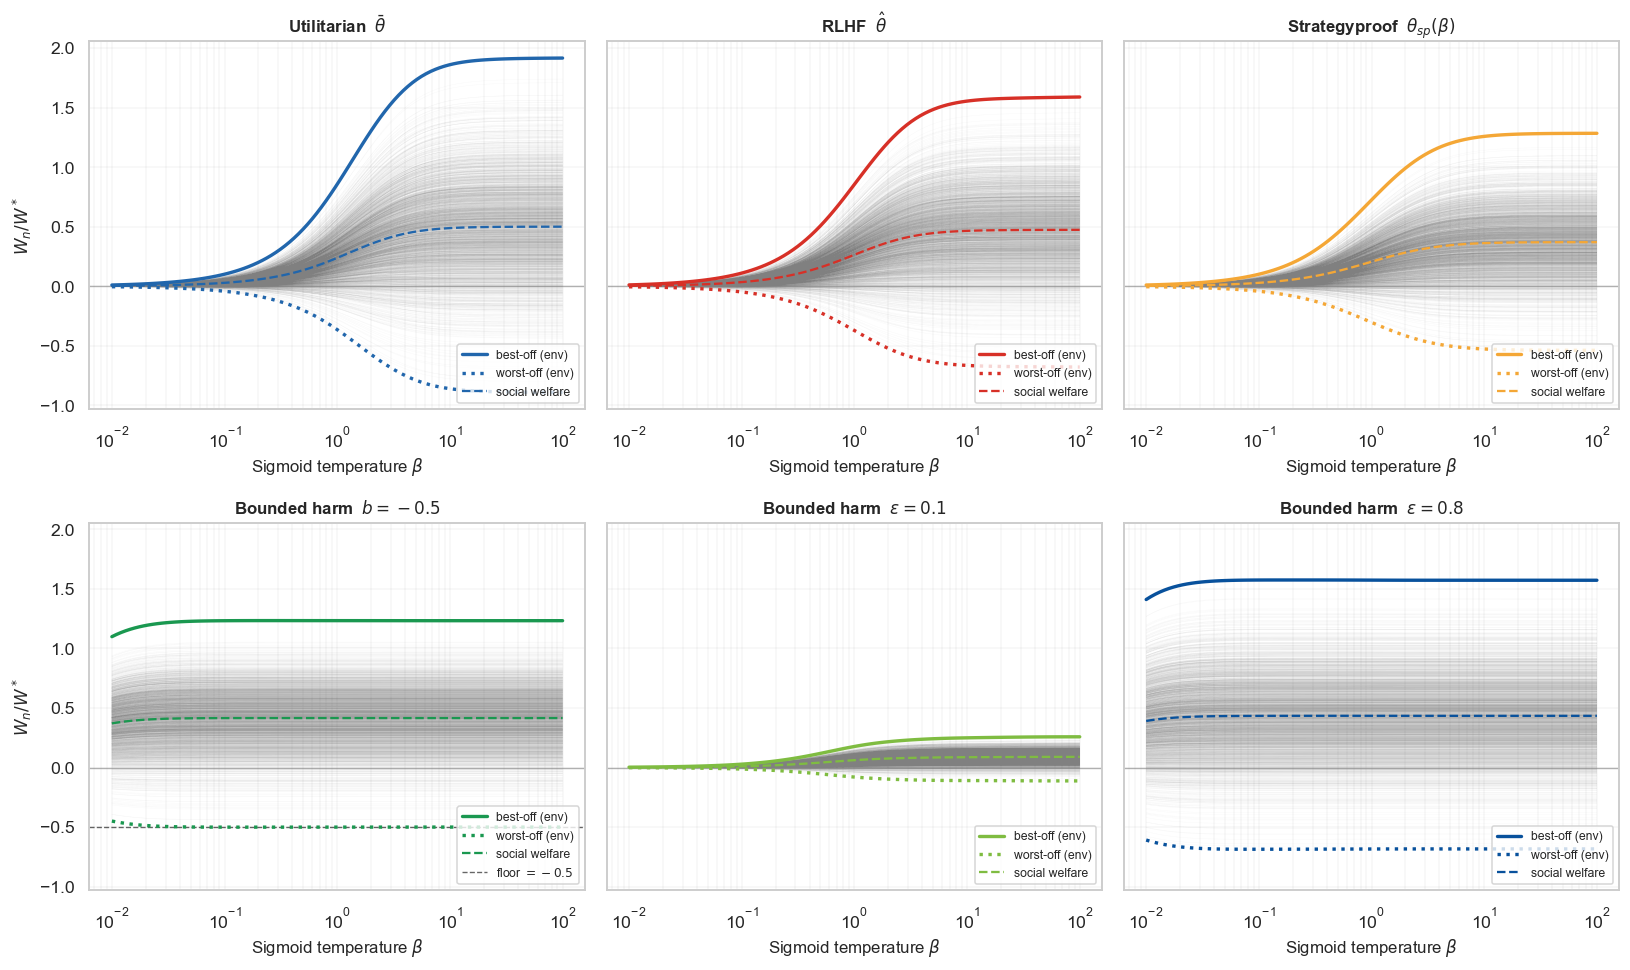


at β=100.0:
  Utilitarian     min -0.8921   max +1.9157   mean +0.4999
  RLHF            min -0.6785   max +1.5888   mean +0.4735
  Strategyproof   min -0.5383   max +1.2839   mean +0.3698
  BH  b=-0.5      ||θ_c||=1070.800   min -0.5002   max +1.2329   mean +0.4152
  BH  ε=0.1       ||θ_c||=27.631   min -0.1124   max +0.2580   mean +0.0894
  BH  ε=0.8       ||θ_c||=2762.502   min -0.6834   max +1.5725   mean +0.4341


In [28]:
# 2x3 mechanism comparison.
#   Top row:    Utilitarian | RLHF | Strategyproof    (θ already swept in cell 10)
#   Bottom row: BH b=-0.5   | BH ε=0.1 | BH ε=0.8     (static θ_c via phi_inv at β=1)
# x-axis is β; θ_c for each constrained mechanism is pinned by phi_inv at β=1
# and held fixed across the sweep.

# --- Solve the three bounded-harm variants requested ---
hub = 0.5 * np.abs(alpha_q @ Theta.T).mean(axis=0)

print("Solving BH variants ...")
# threshold in raw welfare units (-0.5 in normalized W/W* units → -0.5·W* in raw)
psi_bh_neg05, _, _ = solve_constrained_lp(
    theta_bar, Theta, -0.5 * W_star * np.ones(N_AGENTS), alpha_q, verbose=False)
psi_bh_eps01, _, _ = solve_constrained_lp(
    theta_bar, Theta, -0.1 * hub, alpha_q, verbose=False)
psi_bh_eps08, _, _ = solve_constrained_lp(
    theta_bar, Theta, -0.8 * hub, alpha_q, verbose=False)

# --- Bottom-row mechanisms: phi_inv at β=1, fixed θ_c, sweep β ---
beta_calib = 1.0
BOTTOM_PSI = {
    "BH  b=-0.5":  psi_bh_neg05,
    "BH  ε=0.1":   psi_bh_eps01,
    "BH  ε=0.8":   psi_bh_eps08,
}
THETA_C = {lbl: phi_inv(psi_lp, beta_calib, alpha_q, theta_init=np.zeros(K_DIM))
           for lbl, psi_lp in BOTTOM_PSI.items()}

W_bot = {}
for lbl, theta_c in THETA_C.items():
    W = np.zeros((len(betas), N_AGENTS))
    for j, b in enumerate(betas):
        W[j] = per_agent_welfare(theta_c, b, Theta, alpha_q) / W_star
    W_bot[lbl] = W

agg_bot = {lbl: {"max": W.max(axis=1), "min": W.min(axis=1), "mean": W.mean(axis=1)}
           for lbl, W in W_bot.items()}

# --- Style ---
mech_titles_full = {
    "Utilitarian":   r"Utilitarian  $\bar\theta$",
    "RLHF":          r"RLHF  $\hat\theta$",
    "Strategyproof": r"Strategyproof  $\theta_{sp}(\beta)$",
    "BH  b=-0.5":    r"Bounded harm  $b=-0.5$",
    "BH  ε=0.1":     r"Bounded harm  $\varepsilon=0.1$",
    "BH  ε=0.8":     r"Bounded harm  $\varepsilon=0.8$",
}
mech_colors_full = {
    "Utilitarian":   "#2166ac",
    "RLHF":          "#d73027",
    "Strategyproof": "#f4a736",
    "BH  b=-0.5":    "#1a9850",
    "BH  ε=0.1":     "#7fbc41",
    "BH  ε=0.8":     "#08519c",
}
TOP    = ["Utilitarian", "RLHF", "Strategyproof"]
BOTTOM = ["BH  b=-0.5", "BH  ε=0.1", "BH  ε=0.8"]

def _draw(ax, lbl, x, W, rec, color, floor=None):
    ax.plot(x, W,           color="gray", alpha=0.05, lw=0.3, zorder=1)
    ax.plot(x, rec["max"],  color=color, lw=2.2, ls="-",  label="best-off (env)",  zorder=4)
    ax.plot(x, rec["min"],  color=color, lw=2.2, ls=":",  label="worst-off (env)", zorder=4)
    ax.plot(x, rec["mean"], color=color, lw=1.5, ls="--", label="social welfare", zorder=3)
    ax.axhline(0, color="grey", lw=0.9, ls="-", alpha=0.6)
    if floor is not None:
        ax.axhline(floor, color="black", lw=0.9, ls="--", alpha=0.6,
                   label=fr"floor $= {floor:g}$")
    ax.set_xscale("log")
    ax.set_xlabel(r"Sigmoid temperature $\beta$", fontsize=11)
    ax.set_title(mech_titles_full[lbl], fontweight="bold", fontsize=11)
    ax.grid(True, which="both", alpha=0.18)
    ax.legend(fontsize=8, loc="lower right")

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)
for ax, lbl in zip(axes[0], TOP):
    _draw(ax, lbl, betas, W_per_agent[lbl], agg[lbl], mech_colors_full[lbl])
for ax, lbl in zip(axes[1], BOTTOM):
    fl = -0.5 if lbl == "BH  b=-0.5" else None
    _draw(ax, lbl, betas, W_bot[lbl], agg_bot[lbl], mech_colors_full[lbl], floor=fl)
axes[0, 0].set_ylabel(r"$W_n / W^*$", fontsize=11)
axes[1, 0].set_ylabel(r"$W_n / W^*$", fontsize=11)
# fig.suptitle(f"CoAlign: best-off and worst-off welfare vs β\n"
#              f"(top: unconstrained baselines; bottom: bounded-harm variants, $\\theta_c$ via phi$^{{-1}}$ at β=1; "
#              f"{N_AGENTS:,} annotators)",
#              fontweight="bold", fontsize=12)
plt.tight_layout(); plt.show()

print(f"\nat β={betas[-1]:.1f}:")
for lbl in TOP:
    print(f"  {lbl:14s}  min {agg[lbl]['min'][-1]:+.4f}   "
          f"max {agg[lbl]['max'][-1]:+.4f}   mean {agg[lbl]['mean'][-1]:+.4f}")
for lbl in BOTTOM:
    print(f"  {lbl:14s}  ||θ_c||={np.linalg.norm(THETA_C[lbl]):.3f}   "
          f"min {agg_bot[lbl]['min'][-1]:+.4f}   "
          f"max {agg_bot[lbl]['max'][-1]:+.4f}   mean {agg_bot[lbl]['mean'][-1]:+.4f}")


### §9.4 Welfare distribution at deployment — apples-to-apples comparison

For each mechanism (unconstrained and welfare-constrained), compute the *deployed* per-agent welfare at $\beta\to\infty$:

* Utilitarian: $W_n = \theta_n^\top\psi^\star(\bar\theta_w)$
* RLHF: $W_n = \theta_n^\top\psi^\star(\hat\theta_{\rm RLHF})$
* SP (welfare-weighted): $W_n = \theta_n^\top\psi^\infty_{w,{\rm sp}}$ where $\psi^\infty_{w,{\rm sp}} = \tfrac1N\sum_m \psi^\star(\theta_m)$
* BH variants: $W_n = \theta_n^\top\psi^h_{\rm LP}$
* PS variants: $W_n = \theta_n^\top\psi^{\rm ps}_{\rm LP}$

Then sort welfare *per mechanism* (rank 0 = that mechanism's worst-off, rank $N{-}1$ = that mechanism's best-off) and plot all nine curves on one axis. Reads directly: under each mechanism, where does the worst-off agent sit, and how much best-off welfare is sacrificed to lift the floor?

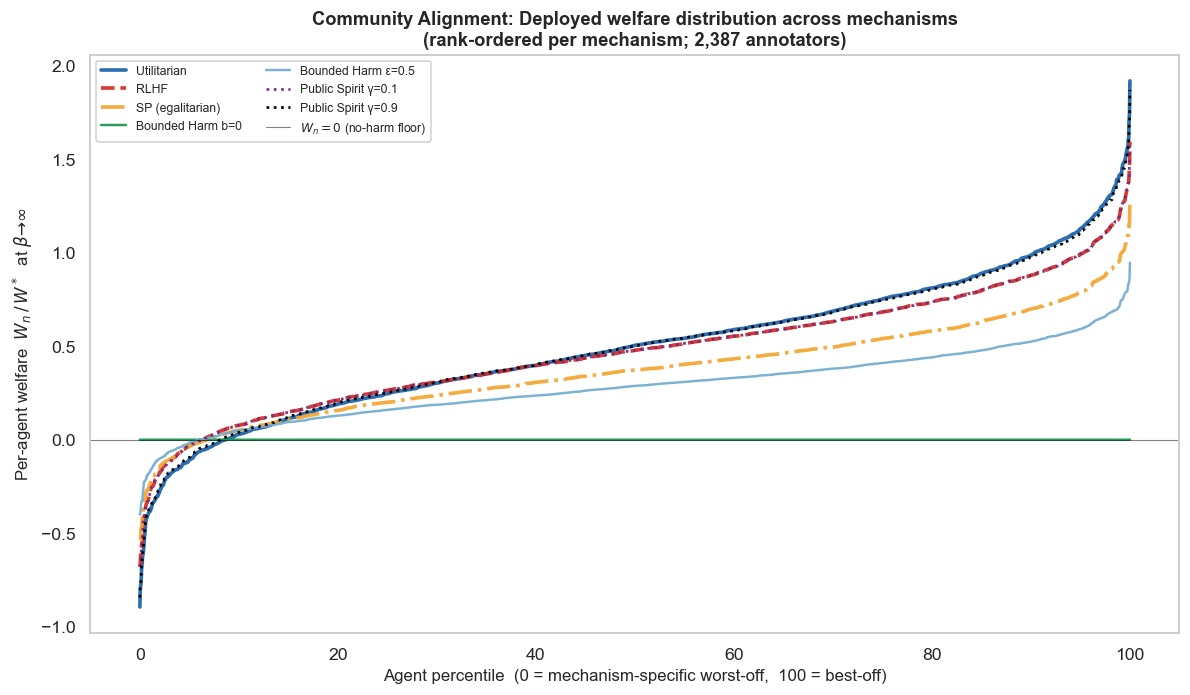


mechanism                       worst        q05        q25     median        q75        q95       best       mean
  Utilitarian                 -0.8945    -0.1082    +0.2458    +0.5044    +0.7518    +1.1280    +1.9184    +0.5000
  RLHF                        -0.6798    -0.0326    +0.2649    +0.4773    +0.6833    +0.9929    +1.5931    +0.4740
  SP (egalitarian)            -0.5384    -0.0325    +0.1994    +0.3723    +0.5403    +0.7895    +1.2841    +0.3698
  Bounded Harm b=0            -0.0000    -0.0000    +0.0000    +0.0000    +0.0000    +0.0000    +0.0000    +0.0000
  Bounded Harm ε=0.5          -0.4006    -0.0171    +0.1595    +0.2872    +0.4102    +0.5919    +0.9470    +0.2846
  Public Spirit γ=0.1         -0.6798    -0.0326    +0.2649    +0.4773    +0.6833    +0.9929    +1.5931    +0.4740
  Public Spirit γ=0.9         -0.8438    -0.0940    +0.2511    +0.5002    +0.7451    +1.1063    +1.8695    +0.4996


In [ ]:
# §9.4 — Asymptotic per-agent welfare distribution per mechanism.

def psi_star(theta_c, alpha):
    return 0.5 * (alpha * np.sign(alpha @ theta_c)[:, None]).mean(axis=0)

# Unconstrained asymptotes
psi_util_inf = psi_star(theta_bar,  alpha_q)
psi_rlhf_inf = psi_star(theta_rlhf, alpha_q)
psi_sp_inf   = np.array([psi_star(theta_n, alpha_q) for theta_n in Theta]).mean(axis=0)

ALL_MECH_PSI = {
    "Utilitarian":            psi_util_inf,
    "RLHF":                   psi_rlhf_inf,
    "SP (egalitarian)":       psi_sp_inf,
    "Bounded Harm b=0":       CONSTRAINED_PSI["BH  b=0"],
    # "Bounded Harm b=ψ_sp":  CONSTRAINED_PSI["BH  b=ψ_sp"],   # uncomment to include
    "Bounded Harm ε=0.5":     CONSTRAINED_PSI["BH  ε=0.5"],
    "Public Spirit γ=0.1":    CONSTRAINED_PSI["PS  γ=0.1"],
    # "Public Spirit γ=0.75": CONSTRAINED_PSI["PS  γ=0.75"],   # uncomment to include
    "Public Spirit γ=0.9":    CONSTRAINED_PSI["PS  γ=0.9"],
}

W_per_mech = {lbl: (Theta @ psi_lp) / W_star for lbl, psi_lp in ALL_MECH_PSI.items()}

mech_styles = {
    "Utilitarian":            ("#2166ac", "-",  2.4),
    "RLHF":                   ("#d73027", "--", 2.4),
    "SP (egalitarian)":  ("#f4a736", "-.", 2.4),
    "Bounded Harm b=0":                ("#1a9850", "-",  1.6),
    # "BH  b=ψ_sp":             ("#08519c", "-",  1.6),
    "Bounded Harm ε=0.5":              ("#74add1", "-",  1.6),
    "Public Spirit γ=0.1":              ("#762a83", ":",  1.8),
    # "PS  γ=0.75":             ("#dd3497", ":",  1.8),
    "Public Spirit γ=0.9":              ("#000000", ":",  1.8),
}

percentile = np.linspace(0, 100, N_AGENTS)

fig, ax = plt.subplots(figsize=(11, 6.5))
for lbl, W in W_per_mech.items():
    color, ls, lw = mech_styles.get(lbl, ("gray", "-", 1.0))
    ax.plot(percentile, np.sort(W), color=color, ls=ls, lw=lw, label=lbl, alpha=0.95)

ax.axhline(0, color="black", lw=0.7, alpha=0.5,
           label=r"$W_n=0$ (no-harm floor)")
ax.set_xlabel(r"Agent percentile  (0 = mechanism-specific worst-off,  100 = best-off)", fontsize=11)
ax.set_ylabel(r"Per-agent welfare  $W_n\,/\,W^*$  at $\beta\to\infty$", fontsize=11)
# ax.set_title(f"Community Alignment: Deployed welfare distribution across mechanisms"
#              f"\n(rank-ordered per mechanism; {N_AGENTS:,} annotators)",
#              fontweight="bold", fontsize=18)
ax.legend(fontsize=8, loc="upper left", ncol=2, framealpha=0.9)
ax.grid(False)
plt.tight_layout(); plt.show()

# Summary table
print(f"\n{'mechanism':26s}  {'worst':>9s}  {'q05':>9s}  {'q25':>9s}  "
      f"{'median':>9s}  {'q75':>9s}  {'q95':>9s}  {'best':>9s}  {'mean':>9s}")
for lbl, W in W_per_mech.items():
    qs = np.quantile(W, [0.0, 0.05, 0.25, 0.5, 0.75, 0.95, 1.0])
    print(f"  {lbl:24s}  " + "  ".join(f"{q:+9.4f}" for q in qs) + f"  {W.mean():+9.4f}")